In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# pipeline
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.compose import ColumnTransformer # multi-preprocessing

# prosesing
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.model_selection import (train_test_split, StratifiedKFold, cross_validate, 
                                    RandomizedSearchCV, GridSearchCV)

from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score, classification_report,
                            accuracy_score, confusion_matrix,average_precision_score,
                            precision_recall_curve)

# ini library dari hybrid method
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN, SMOTETomek 
from imblearn.over_sampling import BorderlineSMOTE

# model
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression


import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('Loan_default.csv')
df.head(10)

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0
5,A9S62RQ7US,25,90298,90448,720,18,2,22.72,24,0.10,High School,Unemployed,Single,Yes,No,Business,Yes,1
6,H8GXPAOS71,38,111188,177025,429,80,1,19.11,12,0.16,Bachelor's,Unemployed,Single,Yes,No,Home,Yes,0
7,0HGZQKJ36W,56,126802,155511,531,67,4,8.15,60,0.43,PhD,Full-time,Married,No,No,Home,Yes,0
8,1R0N3LGNRJ,36,42053,92357,827,83,1,23.94,48,0.20,Bachelor's,Self-employed,Divorced,Yes,No,Education,No,1
9,CM9L1GTT2P,40,132784,228510,480,114,4,9.09,48,0.33,High School,Self-employed,Married,Yes,No,Other,Yes,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  str    
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  str    
 11  EmploymentType  255347 non-null  str    
 12  MaritalStatus   255347 non-null  str    
 13  HasMortgage     255347 non-null  str    
 14  HasDependents   255347 non-null  str    
 15  LoanPurpose     255347 non-null  str    
 16  HasCoSigner     255347 non-null  str    
 17  Default         25534

In [4]:
df.shape

(255347, 18)

In [5]:
df.isnull().sum()

LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

# EDA

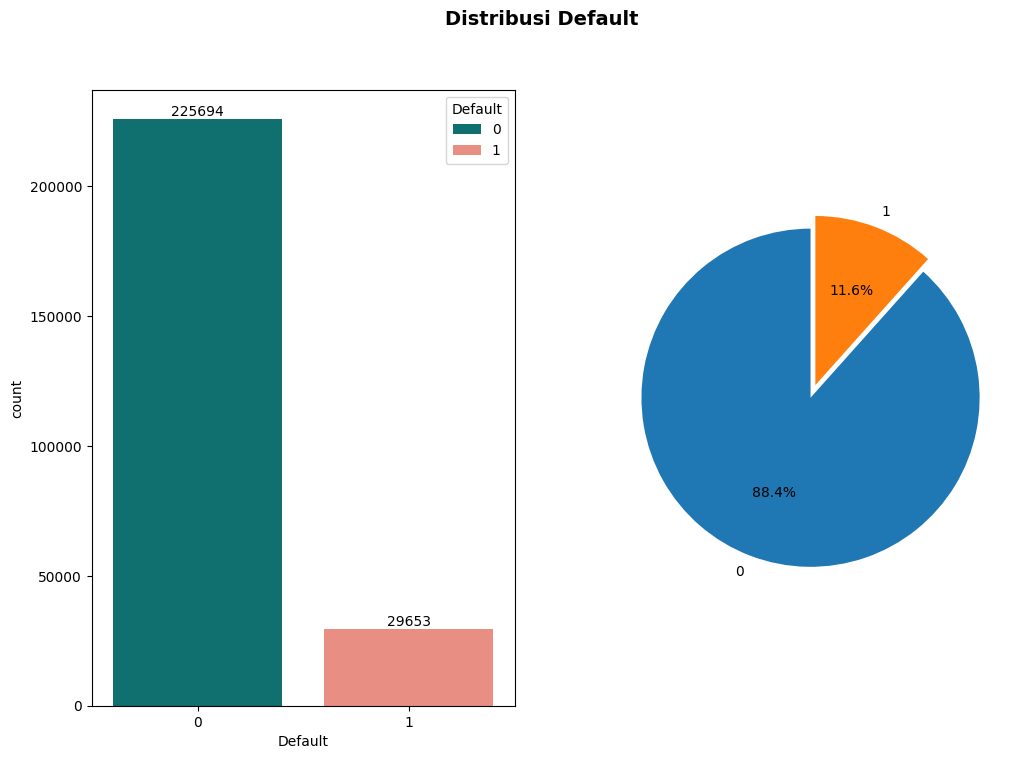

In [7]:
fig, axes = plt.subplots(1,2 ,figsize=(12,8))
sns.countplot(data=df, x='Default', hue='Default', palette=['teal','salmon'], ax=axes[0])
for i in axes[0].containers:
    axes[0].bar_label(i)

count_default = df['Default'].value_counts()
plt.pie(count_default, labels=count_default.index, autopct='%1.1f%%', startangle=90, 
        explode=(0, 0.08))

fig.suptitle('Distribusi Default', fontsize=14, fontweight='bold')

plt.show()

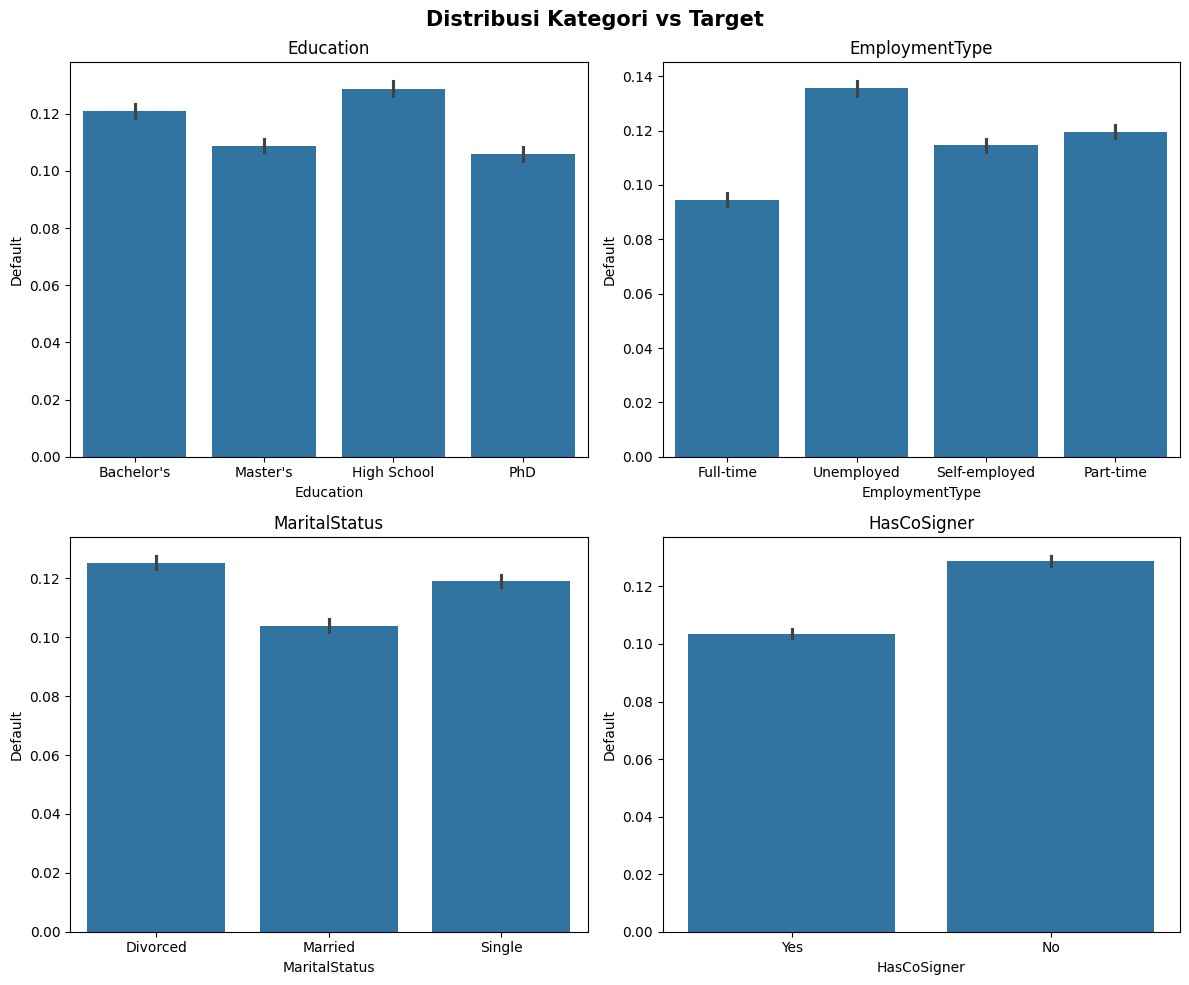

In [8]:
fig, axes = plt.subplots(2,2, figsize=(12,10))
kategori_cols = ['Education', 'EmploymentType', 'MaritalStatus', 'HasCoSigner']
axes = axes.flatten()

for i, col in enumerate(kategori_cols):
    # sns.countplot(data=df, x=col, hue='Default', ax=axes[i])
    sns.barplot(data=df, x=col, y='Default', ax=axes[i])
    # for j in axes[i].containers:
    #     axes[i].bar_label(j)
    plt.suptitle('Distribusi Kategori vs Target', fontweight='bold', fontsize=15)
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

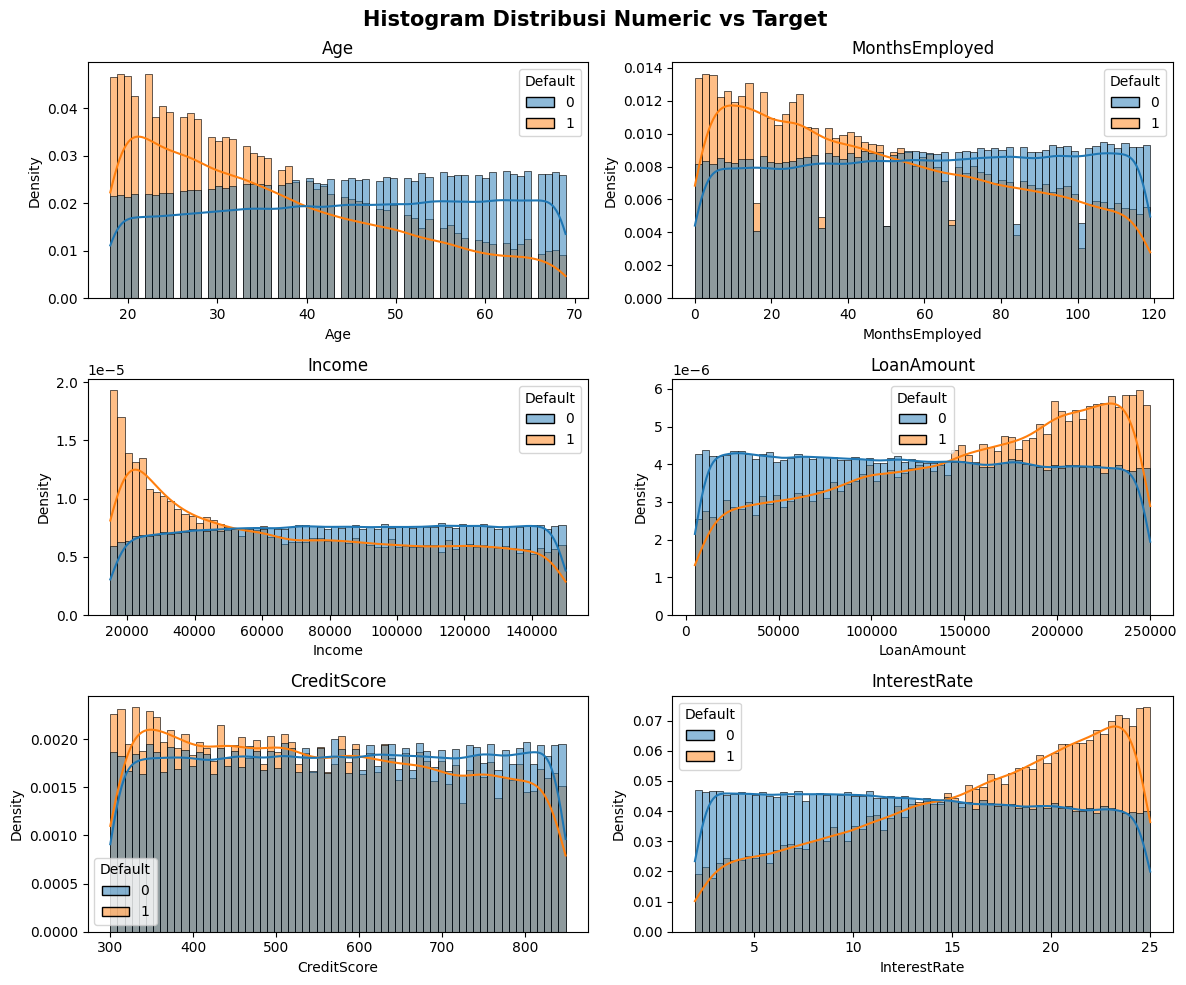

In [9]:
fig, axes = plt.subplots(3,2, figsize=(12,10))
num_cols = ['Age', 'MonthsEmployed', 'Income', 'LoanAmount', 'CreditScore', 'InterestRate']
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, hue='Default', kde=True, stat='density', 
                 common_norm=False, ax=axes[i])
    plt.suptitle('Histogram Distribusi Numeric vs Target', fontweight='bold', fontsize=15)
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

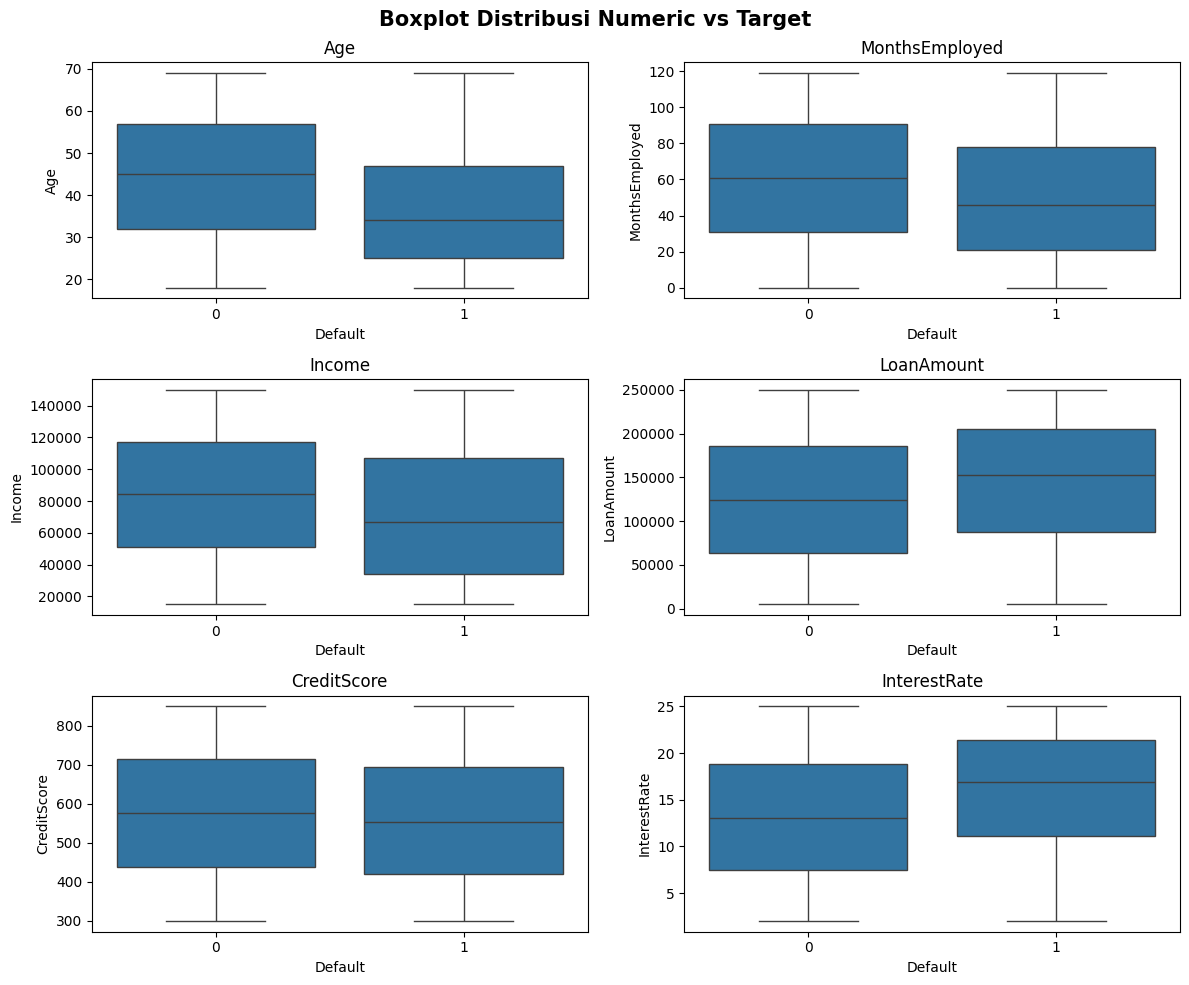

In [10]:
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()

for i, cols in enumerate(num_cols):
    sns.boxplot(data=df, x='Default', y=cols, ax=axes[i])
    plt.suptitle('Boxplot Distribusi Numeric vs Target', fontweight='bold', fontsize=15)
    axes[i].set_title(cols)

plt.tight_layout()
plt.show()

Berdasarkan visualisasi:
1. InterestRate dan LoanAmount menunjukkan perbedaan distribusi yang cukup jelas antara kelas default dan non-default, sehingga berpotensi menjadi fitur yang membedakan
2. Income dan CreditScore memiliki distribusi yang saling tumpang tindih (overlap) cukup besar, sehingga kurang kuat sebagai pembeda jika digunakan secara individual
3. LoanTerm dan DTIRatio menunjukkan perbedaan yang relatif kecil antar kelas bahkan hampir overlap total
4. Ternyaya Age ynng palig bisa membedakan kelas mesti tidak terlalu besar

Nah jadi secara keseluruhan tidak ada fitur yang memebedakan kelas secara sempurna tetapi ada beberapa nilai yang di dominasi oleh yes (1)

<Axes: >

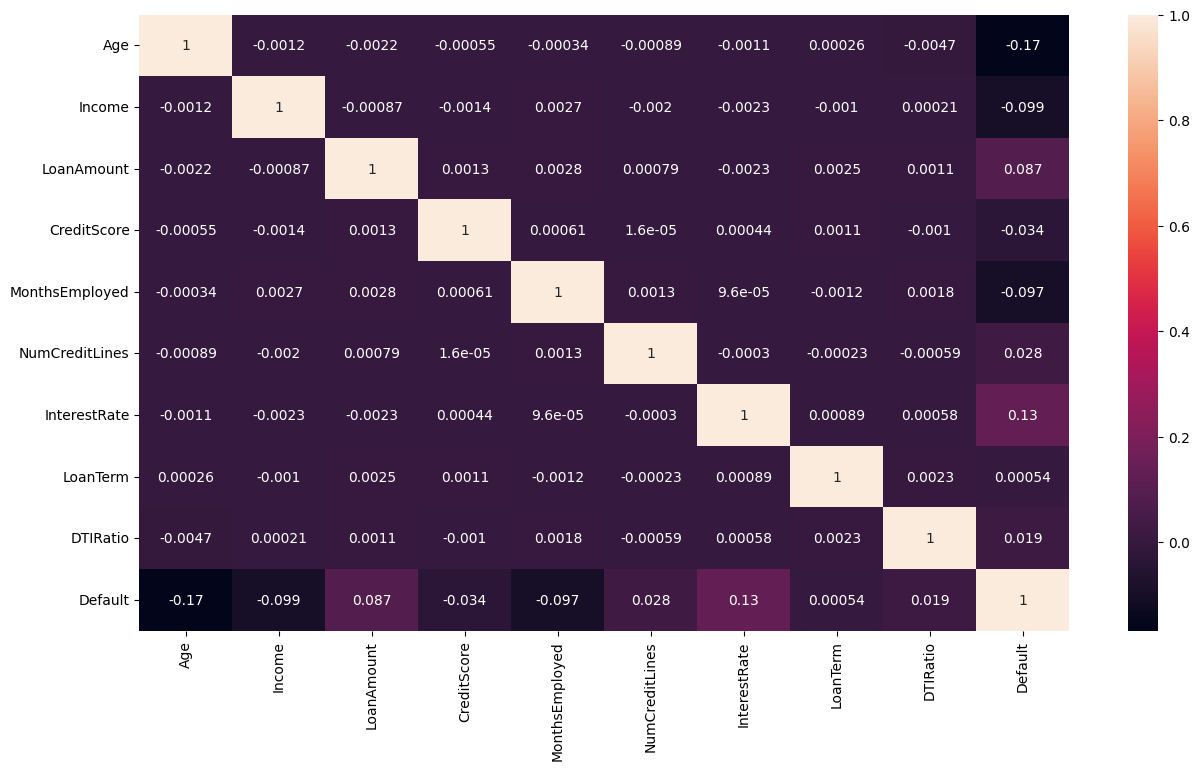

In [11]:
plt.figure(figsize=(15,8))

df_heat = df.copy()
heat_num = (df_heat.select_dtypes(include=np.number).columns.tolist())
heat_corr = df_heat[heat_num].corr()

sns.heatmap(data=heat_corr, annot=True)

In [12]:
heat_corr

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
Age,1.000000,-0.001244,-0.002213,-0.000548,-0.000341,-0.000890,-0.001127,0.000263,-0.004689,-0.167783
Income,-0.001244,1.000000,-0.000865,-0.001430,0.002675,-0.002016,-0.002303,-0.000998,0.000205,-0.099119
LoanAmount,-0.002213,-0.000865,1.000000,0.001261,0.002817,0.000794,-0.002291,0.002538,0.001122,0.086659
CreditScore,-0.000548,-0.001430,0.001261,1.000000,0.000613,0.000016,0.000436,0.001130,-0.001039,-0.034166
MonthsEmployed,-0.000341,0.002675,0.002817,0.000613,1.000000,0.001267,0.000096,-0.001166,0.001765,-0.097374
NumCreditLines,-0.000890,-0.002016,0.000794,0.000016,0.001267,1.000000,-0.000297,-0.000226,-0.000586,0.028330
InterestRate,-0.001127,-0.002303,-0.002291,0.000436,0.000096,-0.000297,1.000000,0.000892,0.000575,0.131273
LoanTerm,0.000263,-0.000998,0.002538,0.001130,-0.001166,-0.000226,0.000892,1.000000,0.002273,0.000545
DTIRatio,-0.004689,0.000205,0.001122,-0.001039,0.001765,-0.000586,0.000575,0.002273,1.000000,0.019236
Default,-0.167783,-0.099119,0.086659,-0.034166,-0.097374,0.028330,0.131273,0.000545,0.019236,1.000000


Kalau dilihat secara keseluruhan tidak terdapat korelasi yang kuat antar fitur maupun terhadap target. Hal ini menunjukkan bahwa hubungan antar variabel bersifat lemah secara linear, sehingga diperlukan model machine learning untuk menangkap pola yang lebih kompleks.

# Preprocessing

In [13]:
df.isnull().sum()

LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [16]:
df = df.sample(30000, random_state=42)

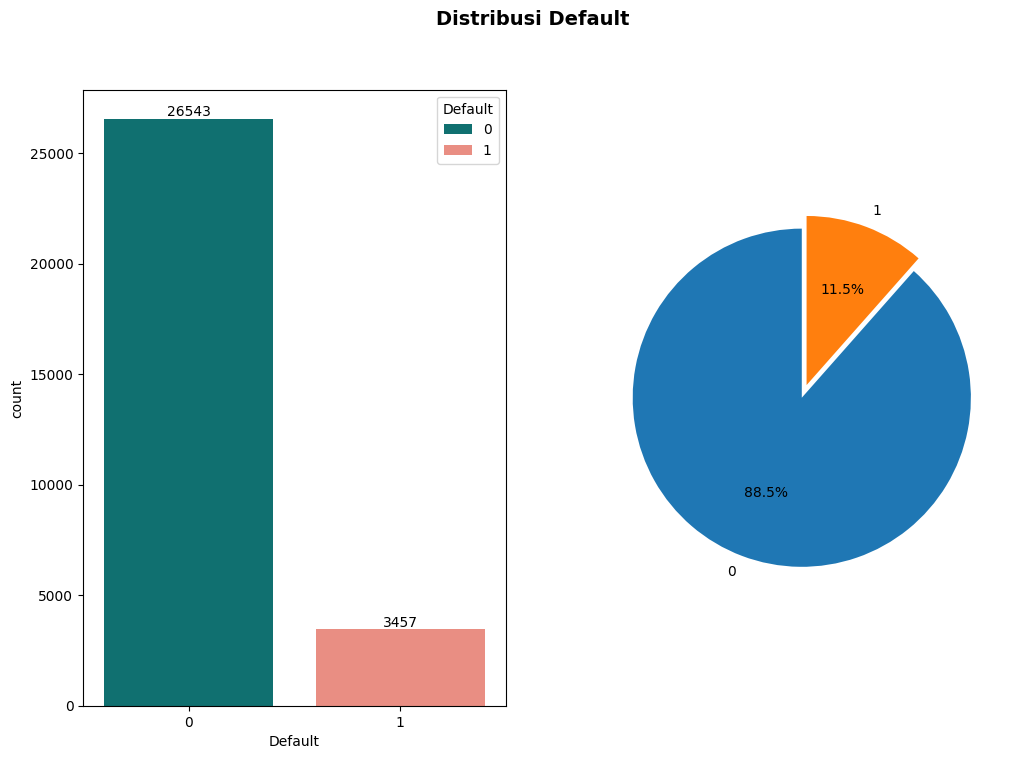

In [17]:
fig, axes = plt.subplots(1,2 ,figsize=(12,8))
sns.countplot(data=df, x='Default', hue='Default', palette=['teal','salmon'], ax=axes[0])
for i in axes[0].containers:
    axes[0].bar_label(i)

count_default = df['Default'].value_counts()
plt.pie(count_default, labels=count_default.index, autopct='%1.1f%%', startangle=90, 
        explode=(0, 0.08))

fig.suptitle('Distribusi Default', fontsize=14, fontweight='bold')

plt.show()

In [18]:
df.drop(columns=['LoanID'], inplace=True)
df.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
51139,55,112656,92393,581,113,2,23.54,36,0.15,PhD,Self-employed,Single,Yes,Yes,Home,No,0
71005,56,91569,131575,641,54,1,15.19,12,0.43,High School,Part-time,Divorced,Yes,Yes,Education,Yes,0
35684,26,78169,75417,569,105,3,18.02,12,0.29,Master's,Part-time,Married,Yes,Yes,Education,Yes,0
174087,26,63033,10804,326,118,1,14.71,24,0.41,High School,Part-time,Single,No,No,Business,Yes,0
137952,24,29665,21182,662,102,3,15.02,60,0.69,PhD,Unemployed,Single,No,Yes,Business,Yes,0


# Feature Engineering

In [19]:
# df_fe = df.copy()

# # rasio pinjaman dengan pendapatan
# df_fe['LoanIncome'] = df_fe['LoanAmount'] / (df_fe['Income'] + 1)
# # rasio bunga pinjaman yang didapat dalam sebulan
# df_fe['MonthlyDebtBurden'] = (df_fe['LoanAmount'] * df_fe['InterestRate'] / 100) /12

In [20]:
# df_fe.head()

In [21]:
df.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
51139,55,112656,92393,581,113,2,23.54,36,0.15,PhD,Self-employed,Single,Yes,Yes,Home,No,0
71005,56,91569,131575,641,54,1,15.19,12,0.43,High School,Part-time,Divorced,Yes,Yes,Education,Yes,0
35684,26,78169,75417,569,105,3,18.02,12,0.29,Master's,Part-time,Married,Yes,Yes,Education,Yes,0
174087,26,63033,10804,326,118,1,14.71,24,0.41,High School,Part-time,Single,No,No,Business,Yes,0
137952,24,29665,21182,662,102,3,15.02,60,0.69,PhD,Unemployed,Single,No,Yes,Business,Yes,0


# Split data

In [22]:
X = df.drop('Default', axis=1)
y = df['Default']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [23]:
ters = df.select_dtypes(include=np.number).columns.tolist()
ters

['Age',
 'Income',
 'LoanAmount',
 'CreditScore',
 'MonthsEmployed',
 'NumCreditLines',
 'InterestRate',
 'LoanTerm',
 'DTIRatio',
 'Default']

## Sortir Fitur Kategori

In [24]:
# utk binary kategori
bin_col = ['HasMortgage','HasDependents','HasCoSigner',]
# utk multi kategori
mul_col = ['EmploymentType','MaritalStatus','LoanPurpose']
# utk kategori yang punya tingkatan urutan
ordinla_col = ['Education']
# kolom yang sudah numerik
numeric_col = ['Age','Income','LoanAmount','CreditScore','MonthsEmployed','NumCreditLines',
                 'InterestRate','LoanTerm','DTIRatio']

# Preprocessing use pipeline

In [25]:
preprocess = ColumnTransformer(transformers=[
    # yg binary
    ('bin', OneHotEncoder(drop='if_binary'), bin_col),
    # multi kategori
    ('multi', OneHotEncoder(drop='first', handle_unknown='ignore'), mul_col),
    # ordinal
    ('ordinal', OrdinalEncoder(categories=[["High School", "Bachelor's", "Master's", "PhD"]]), ordinla_col),
    # normalisasi data numerik
    ('scaler', StandardScaler(), numeric_col)
], remainder='drop' # Ini fokus utk atribut yang di pakai saja, selain itu dihapus
)

# Pemodelan + Metode --> Pipeline

In [26]:
# Model yang digunakan
models = {
    'RandomForest' : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'LightGBM' : LGBMClassifier(n_estimators=100, random_state=42, verbose=-1,n_jobs=-1),
    'LogisticRegression' : LogisticRegression(max_iter=300, n_jobs=-1, random_state=42)
}

# Metode ynag di gunakna
resample = {
    'Baseline' : None,
    'SMOTE-ENN' : SMOTEENN(random_state=42),
    'SMOTE-Tomek' : SMOTETomek(random_state=42),
    'Borderline-SMOTE' : BorderlineSMOTE(random_state=42)
}

## Training Loop

- Kita train model dan mathod yg udh dibuat menggunakan pipeline tdi

In [27]:
# loop utk nama model yang sudah ada
pr_curve_data = []

for name, model in models.items():
    print(f'\n============= {name} =============\n')
    
    # loop utk model dan metodenya
    for method_name, sampler in resample.items():
        print("\n" + "="*20)
        print(f"{method_name}")
        print("="*20)

        # pemanggilan pipelinenya
        if sampler is None: # ini yang baseline, jadi ga manggil resample
            pipeline = ImbPipeline(steps=[
                ('preprocess', preprocess),
                ('model', model)
            ])
        else: # dan ini yang versi pakai metode
            pipeline = ImbPipeline(steps=[
                ('preprocess', preprocess),
                ('resample', sampler),
                ('model', model)
            ])

        # kita train variabeel 'pipeline' karna dia udh bungkus semua baik model dan metodenya
        pipeline.fit(X_train, y_train)
        # ini utk prediksi
        y_pred = pipeline.predict(X_test)
        y_prob = pipeline.predict_proba(X_test)[:, 1]

        # metrik evaluasi yang di pakai 
        pr_auc = average_precision_score(y_test, y_prob)
        roc_auc = roc_auc_score(y_test, y_prob)
        f1 = f1_score(y_test, y_pred)
        confusion = confusion_matrix(y_test, y_pred)
        clas_report = classification_report(y_test, y_pred)

        # kita simpan semua datanya utk dijadikan visual nantinya (semua hasil disini)
# aslinya precision, recall, thresholds
        precision, recall, _ =  precision_recall_curve(y_test, y_prob) # --> utk data kurva PR
        pr_curve_data.append({
            'Label' : f'{name} + {method_name}',
            'Model' : name,
            'Metode' : method_name,
            'Precision' : precision,
            'Recal' : recall,
            'PR-AUC' : pr_auc,
            'F1_score' : f1
        })
        
        print(f"PR-AUC: {pr_auc}")
        print(f"ROC-AUC: {roc_auc}")
        print(f"Confusion Matrix: \n{confusion}")
        print(f"\nClassification Report")
        print(f"{clas_report}")


============= RandomForest =============


Baseline
PR-AUC: 0.28496306686377115
ROC-AUC: 0.7165060341789153
Confusion Matrix: 
[[5304    5]
 [ 682    9]]

Classification Report
              precision    recall  f1-score   support

           0       0.89      1.00      0.94      5309
           1       0.64      0.01      0.03       691

    accuracy                           0.89      6000
   macro avg       0.76      0.51      0.48      6000
weighted avg       0.86      0.89      0.83      6000


SMOTE-ENN
PR-AUC: 0.24644311133335242
ROC-AUC: 0.7258987891298915
Confusion Matrix: 
[[4266 1043]
 [ 349  342]]

Classification Report
              precision    recall  f1-score   support

           0       0.92      0.80      0.86      5309
           1       0.25      0.49      0.33       691

    accuracy                           0.77      6000
   macro avg       0.59      0.65      0.59      6000
weighted avg       0.85      0.77      0.80      6000


SMOTE-Tomek
PR-AUC: 0.248415696

# Visual Performa Model dan Metode 

## Precision-Recall curve tiap Model & Metode

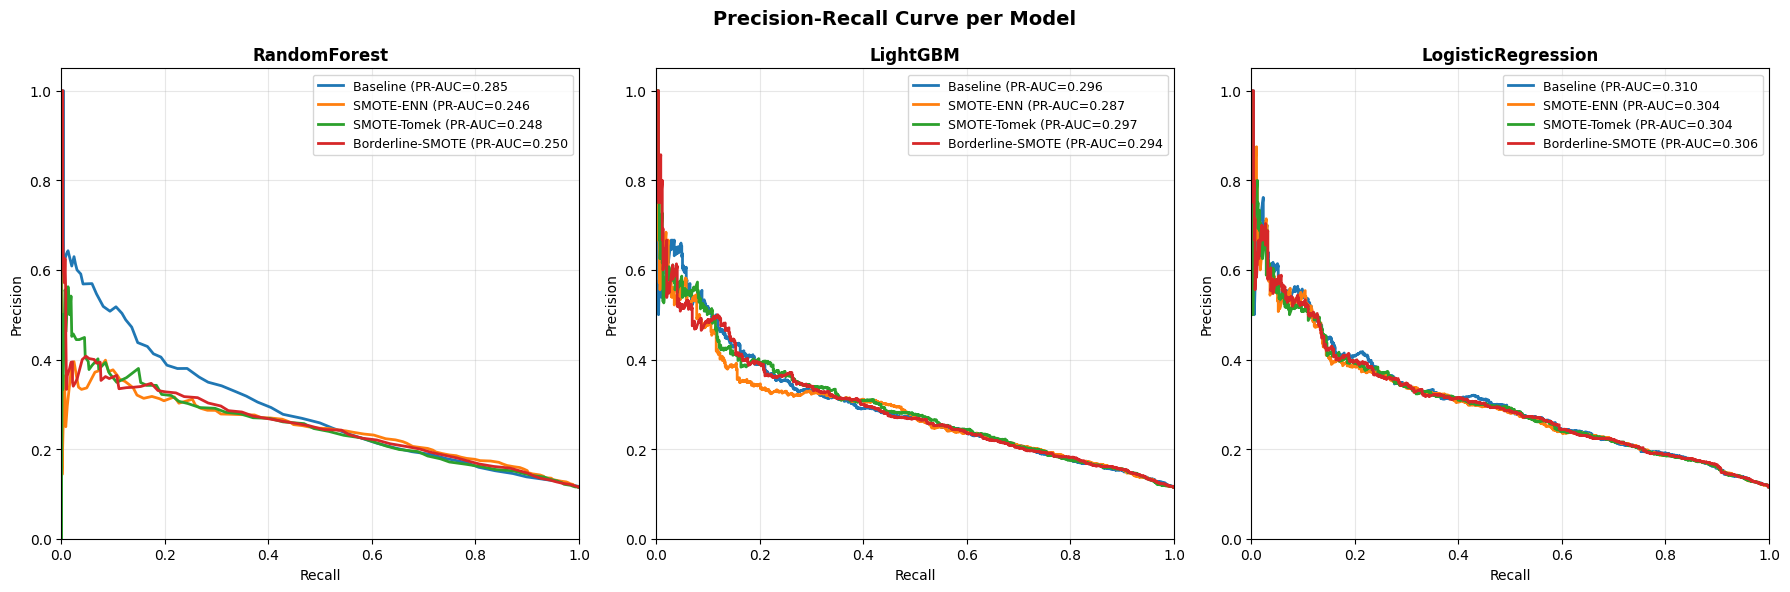

In [28]:
fig, axes = plt.subplots(1,3, figsize=(18,6))
axes = axes.flatten()
model_name = list(models.keys())

for ax, model_col in zip(axes, model_name): # --> pakai zip utk menggabungkan jadi pasangan
    # kita filter hanya data pada model ini
    model_data = [i for i in pr_curve_data if i['Model'] == model_col]
    for j, data in enumerate(model_data):
        ax.plot(data['Recal'], data['Precision'], label=f'{data['Metode']} (PR-AUC={data['PR-AUC']:.3f}',
               lw=2)
    baseline = y_test.mean()
    ax.set_title(model_col, fontweight='bold', fontsize=12)
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.legend(fontsize=9)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.05])
    ax.grid(True, alpha=0.3)

plt.suptitle('Precision-Recall Curve per Model', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

In [29]:
df_eval = pd.DataFrame([{
    'Model' : k['Model'],
    'Metode' : k['Metode'],
    'PR-AUC' : (k['PR-AUC']),
    'F1-score' : k['F1_score']
}for k in pr_curve_data])

In [30]:
df_eval.columns

Index(['Model', 'Metode', 'PR-AUC', 'F1-score'], dtype='str')

## Barplot + Heatmap

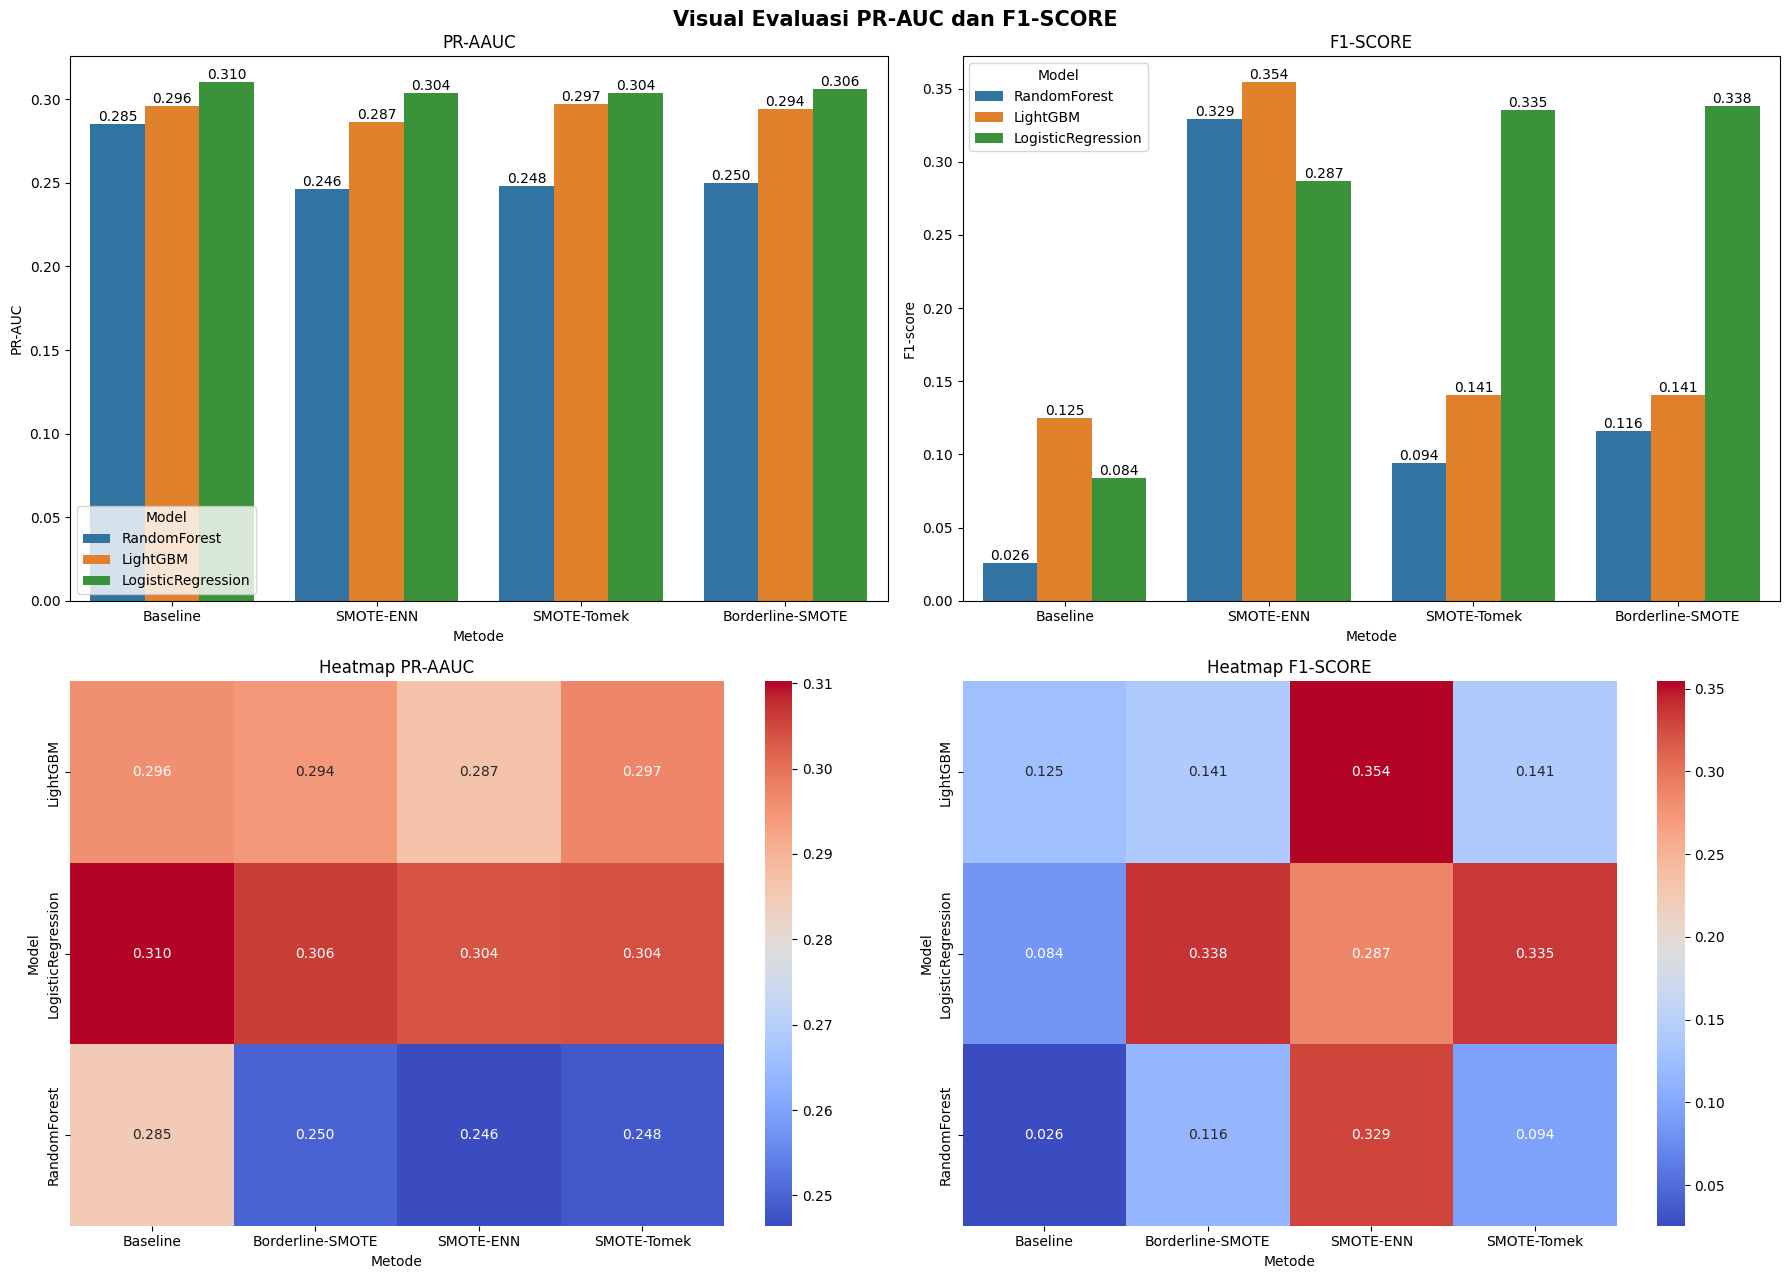

In [31]:
fig, axes = plt.subplots(2,2, figsize=(18,13))
axes = axes.flatten()

metrik = [
    # inisial nama, nama kolom yg udh diseting di result, kita fokus pakai metric pr-auc dan f1 score
    ('PR-AUC', 'PR-AAUC'),  # ---> col(dipakai ambil data), title(cuma nampilin aja)
    ('F1-score', 'F1-SCORE')
]

# utk barplot 
for i, (col, title) in enumerate(metrik):
    sns.barplot(data=df_eval, x='Metode', y=col, hue='Model', ax=axes[i])
    for j in axes[i].containers:
        axes[i].bar_label(j, fmt='%.3f')
    axes[i].set_title(title)

# utk heatmap
for i, (col, title) in enumerate(metrik, start=2):
    pivot = df_eval.pivot(index='Model', columns='Metode', values=col)
    sns.heatmap(data=pivot, annot=True, fmt='.3f',cmap='coolwarm', ax=axes[i])
    axes[i].set_title(f'Heatmap {title}')

plt.suptitle('Visual Evaluasi PR-AUC dan F1-SCORE', fontweight='bold', fontsize=15)
plt.tight_layout()
plt.show()

# Cross Validation

- Disini kita akan mencari model dan method yang paling optimal utk nantinya dipakai di Hyperparameter tuning, diamana tujuanya nannti utk memaksimalkan hasil model dan metode yang paling optomal 

In [32]:
cross_val = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) 

result = []

# score = {
#     'pr_auc' : 'average_precision',
#     'f1_score' : 'f1'
# }

# pemanggilan model
for name, model in models.items():
    for method_mame, sampler in resample.items():

        # pemanggilan model dan method 
        if sampler is None:
            pipeline = ImbPipeline(steps=[
                ('preprocess', preprocess),
                ('model', model)
            ])
        else:
            pipeline = ImbPipeline(steps=[
                ('preprocess',preprocess),
                ('resample', sampler),
                ('model', model)
            ])

        # cross validationnya
        cv = cross_validate(pipeline, X_train,  y_train, cv=cross_val, 
                            scoring=['average_precision', 'f1'], n_jobs=-1)

        # perhitungan scorenya menggunakan mean
        pr_mean = cv['test_average_precision'].mean()
        pr_std = cv['test_average_precision'].std()
        f1_mean = cv['test_f1'].mean()
        f1_std = cv['test_f1'].std()

        # simpan hasilnya menggunakan dictionary
        # ini penting utk visualisasi nantinya karena udh disimpan semua informasi ke result
        result.append({
            'Model' : name,
            'Metode' : method_mame,
            'PR-AUC' : pr_mean,
            'PR-AUC_std' : f1_std,
            'F1_score' : f1_mean,
            'F1_std' : f1_std
        })

In [33]:
df_result = pd.DataFrame(result)
df_result = df_result.sort_values('PR-AUC', ascending=False)
df_result

,Model,Metode,PR-AUC,PR-AUC_std,F1_score,F1_std
8,LogisticRegression,Baseline,0.305084,0.013548,0.060556,0.013548
11,LogisticRegression,Borderline-SMOTE,0.303847,0.007674,0.336995,0.007674
10,LogisticRegression,SMOTE-Tomek,0.301235,0.010289,0.329969,0.010289
9,LogisticRegression,SMOTE-ENN,0.298659,0.004318,0.283296,0.004318
7,LightGBM,Borderline-SMOTE,0.292500,0.018058,0.138179,0.018058
5,LightGBM,SMOTE-ENN,0.291955,0.013614,0.346364,0.013614
4,LightGBM,Baseline,0.291010,0.014172,0.120662,0.014172
6,LightGBM,SMOTE-Tomek,0.287001,0.012412,0.131637,0.012412
0,RandomForest,Baseline,0.281434,0.008251,0.035694,0.008251
3,RandomForest,Borderline-SMOTE,0.257573,0.010179,0.116160,0.010179


- Berdasarkan tabel cross evalution yang sudah dibuat urutan pertama itu di pegang oleh LogisticRegresion dengan metode Baseline, tetapi ketika dilihat dari F1_scorenya dia paling buruk, jadi tidka bisaa dibilang dia paling optimal, sedangakn di Model Logistic Regression dengan Metode Borderline-Smote itu lebih seimbang, dimana PR-AUCnya ada di 0.303 dan F1_scorenya 0.336, jadi yang paling optimal itu ada di Logistic Regression dengan metode borderline
- dan juga di Logistic Regression di metode baseline dia goyang karena PR-AUC_std nya tinggi kli di banding metode lain

# Hyperparameter Tuning

- Kita cari parameter pada model Logistic Regression agar hasilnya makin optimal lah
- Sepertinya bagian max_iter itu gak perlu di tuning karena gak membuat performa meningkat

In [34]:
# kita buat grid beberapa pengujian parameter
lr_parameter = [
    {
        'model__solver': ['liblinear'],
        'model__penalty': ['l1', 'l2'],
        'model__C': [0.0001, 0.001, 0.01, 0.1, 1, 10],
        'model__max_iter': [100, 500, 1000]
    },
    {
        'model__solver': ['lbfgs'],
        'model__penalty': ['l2'],
        'model__C': [0.0001, 0.001, 0.01, 0.1, 1, 10],
        'model__max_iter': [100, 500, 1000]
    }
]

# pipeline utk hasil yang optimal tdi
lr_pipeline = ImbPipeline(steps=[
    ('preprocess', preprocess),
    ('resample', BorderlineSMOTE(random_state=42)),
    ('model', LogisticRegression(random_state=42))
])

# buat ulang cross validatonya
cv_tuning = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# cari/uji hyperparameternya
random_search = RandomizedSearchCV(
    estimator = lr_pipeline,
    param_distributions = lr_parameter,
    n_iter = 50,
    cv = cv_tuning,
    scoring = 'average_precision',
    random_state = 42,
    n_jobs = -1
)
# train tuningya
random_search.fit(X_train, y_train)
random_search.best_params_

{'model__solver': 'liblinear',
 'model__penalty': 'l1',
 'model__max_iter': 500,
 'model__C': 10}

# Evaluasi parameter hasil tuning (Logistic Regression)

- Elaahhhh pe/er gak ada perubahan, cape cape buat cross validation + tuning paramter, perubhanya hampir ga ada pe]u

In [35]:
best = random_search.best_estimator_
y_pred_best = best.predict(X_test)
y_proba_best = best.predict_proba(X_test)[:, 1]

# metrik evaluasi yang di pakai 
pr_auc = average_precision_score(y_test, y_proba_best)
roc_auc = roc_auc_score(y_test, y_proba_best)
confusion = confusion_matrix(y_test, y_pred_best)
clas_report = classification_report(y_test, y_pred_best)

print(f"PR-AUC: {pr_auc}")
print(f"ROC-AUC: {roc_auc}")
print(f"Confusion Matrix: \n{confusion}")
print(f"\nClassification Report")
print(f"{clas_report}")

PR-AUC: 0.30609487364949994
ROC-AUC: 0.7504371655155663
Confusion Matrix: 
[[3780 1529]
 [ 240  451]]

Classification Report
              precision    recall  f1-score   support

           0       0.94      0.71      0.81      5309
           1       0.23      0.65      0.34       691

    accuracy                           0.71      6000
   macro avg       0.58      0.68      0.57      6000
weighted avg       0.86      0.71      0.76      6000

